In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter #it counts occurences in a list of series

In [2]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [4]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

In [5]:
sns.set_theme(style="whitegrid",palette="muted",font_scale=1.05)
pd.set_option("display.max_columns",200)

In [6]:
df=pd.read_csv("customer_data.csv")

In [7]:
df.shape

(10000, 12)

In [8]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df["churn"].value_counts()

0    7963
1    2037
Name: churn, dtype: int64

In [10]:
df.tail()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [12]:
df.describe(include="all")

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [13]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [14]:
df["churn"].value_counts()

0    7963
1    2037
Name: churn, dtype: int64

In [15]:
df["churn"].value_counts(normalize=True)

0    0.7963
1    0.2037
Name: churn, dtype: float64

# **Exploratory Data Analysis ( EDA )**

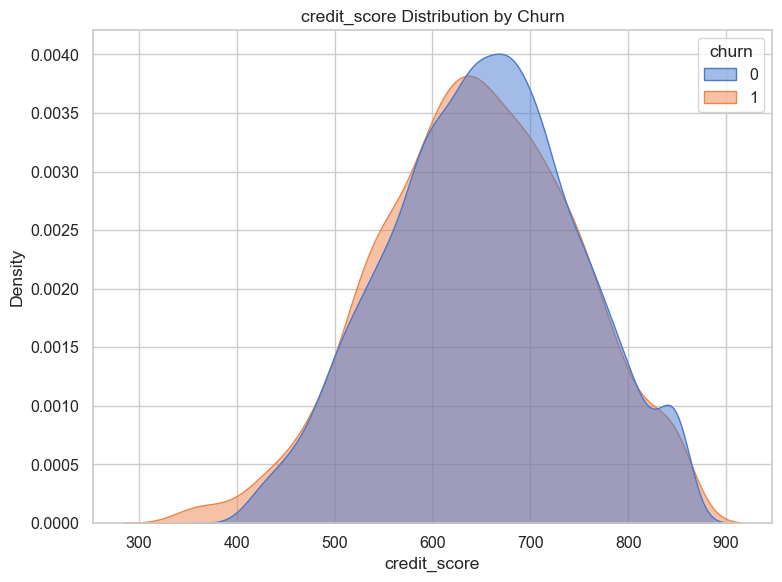

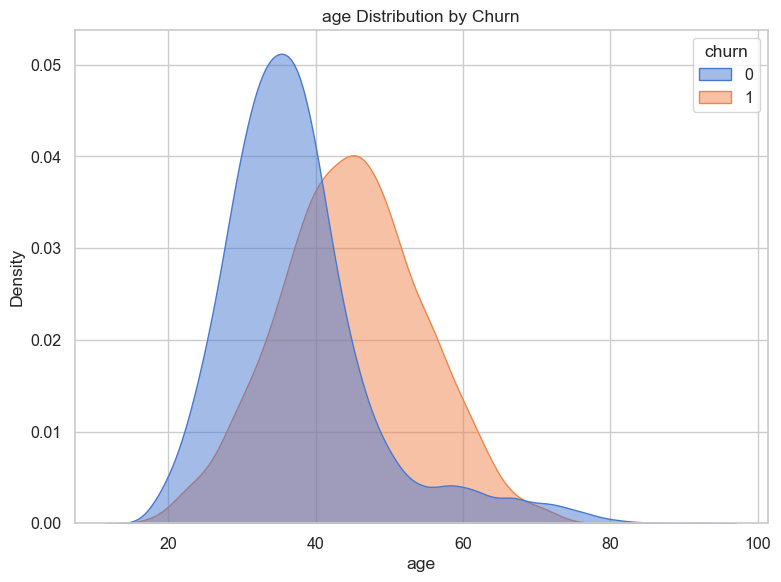

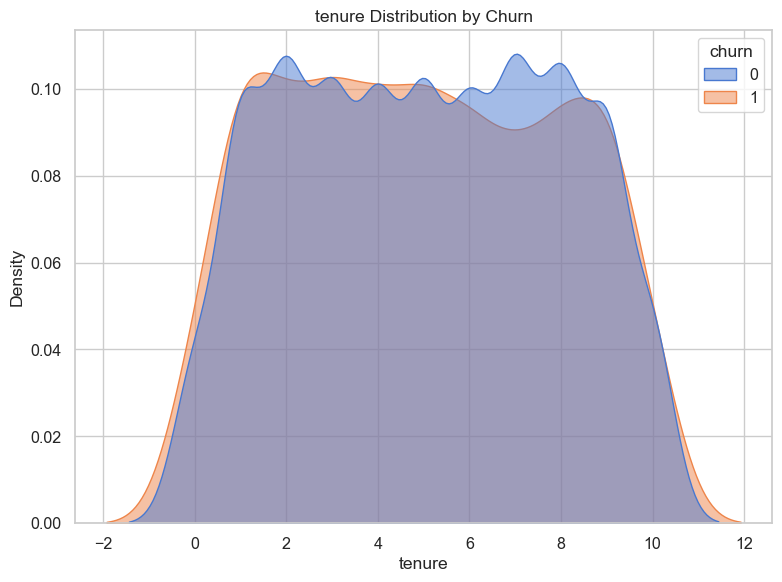

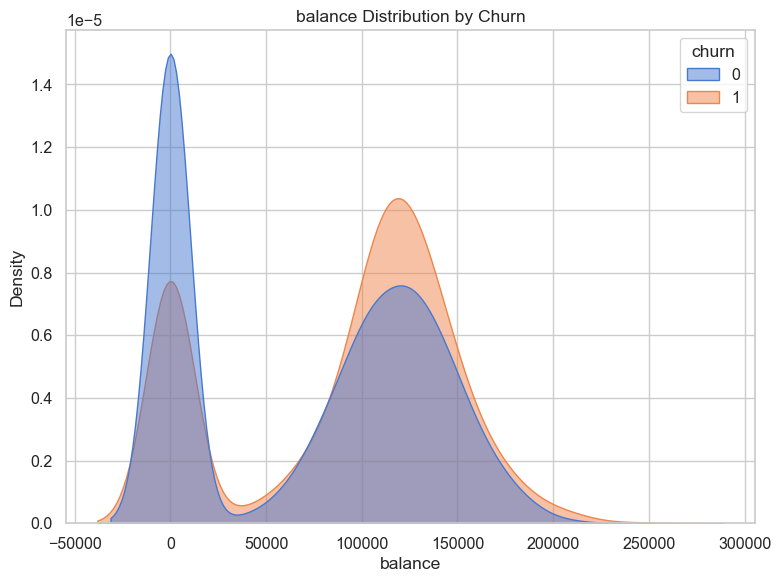

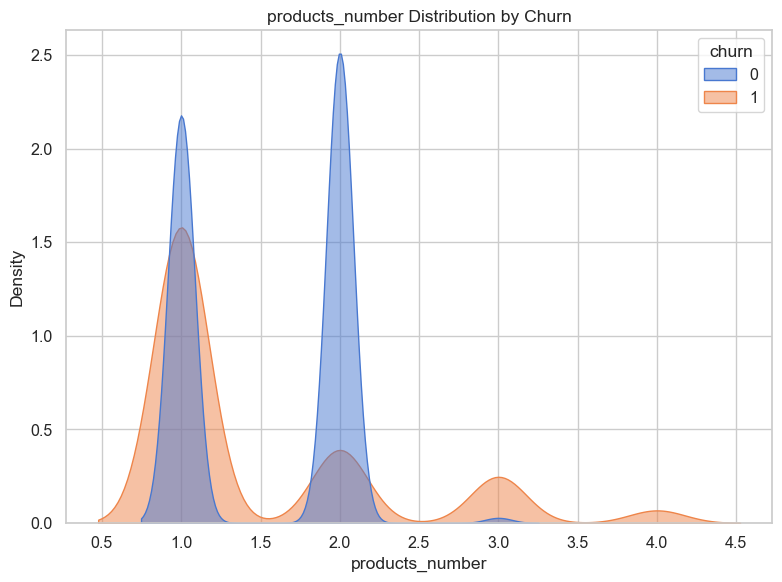

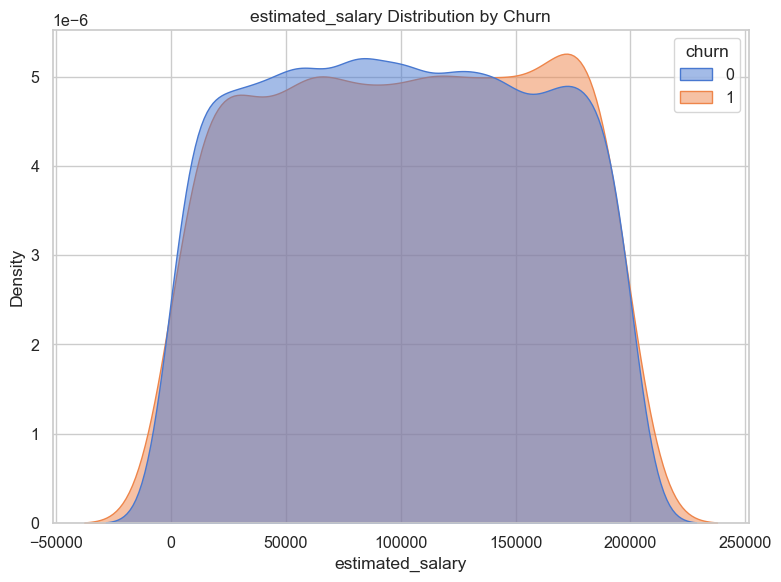

In [17]:
num_cols=["credit_score","age","tenure","balance","products_number","estimated_salary"]

# Distribution plots
for col in num_cols:
  plt.figure(figsize=(8,6))
  sns.kdeplot(data=df,x=col,hue="churn",fill=True,common_norm=False,alpha=0.5)
  plt.title(f"{col} Distribution by Churn")
  plt.tight_layout()
  plt.show()

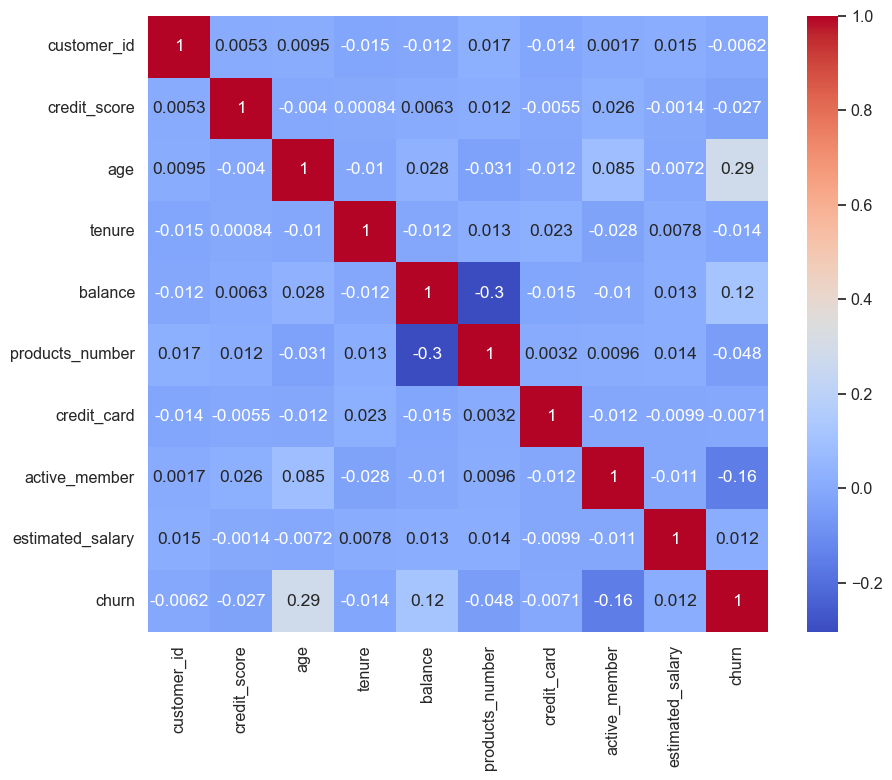

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

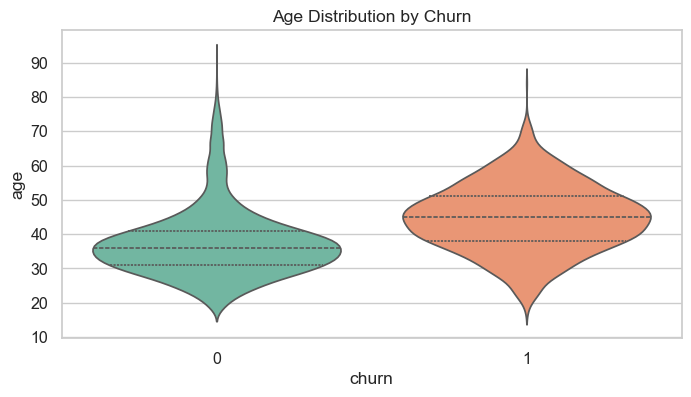

In [19]:
plt.figure(figsize=(8,4))
sns.violinplot(data=df,x="churn",y="age",inner="quart",palette="Set2")
plt.title("Age Distribution by Churn")
plt.show()

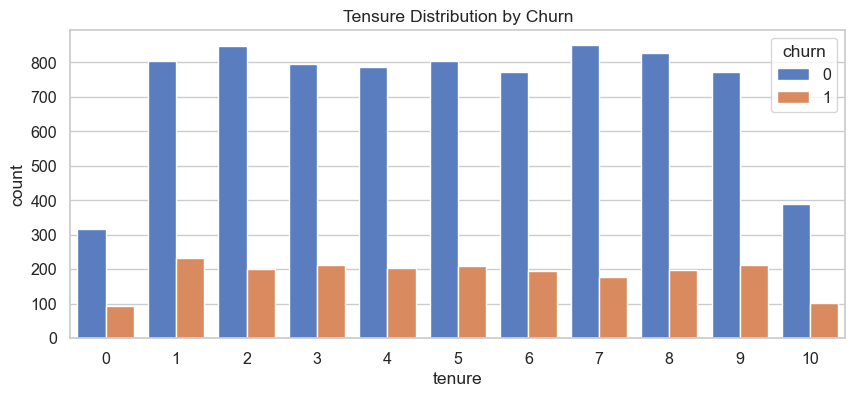

In [20]:
plt.figure(figsize=(10,4))
sns.countplot(df,x="tenure",hue="churn")
plt.title("Tensure Distribution by Churn")
plt.show()

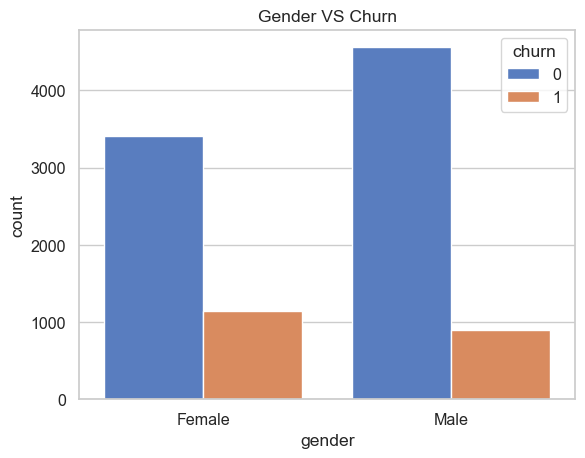

In [21]:
sns.countplot(df,x="gender",hue="churn")
plt.title("Gender VS Churn")
plt.show()

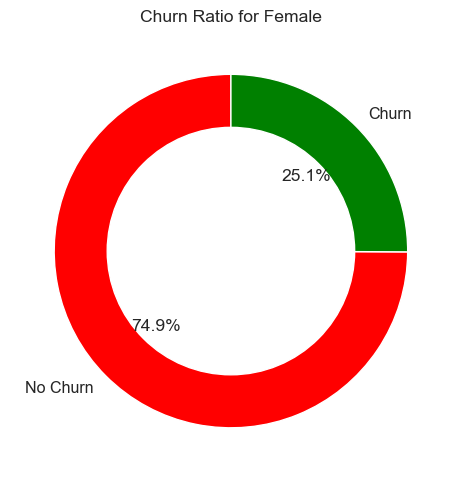

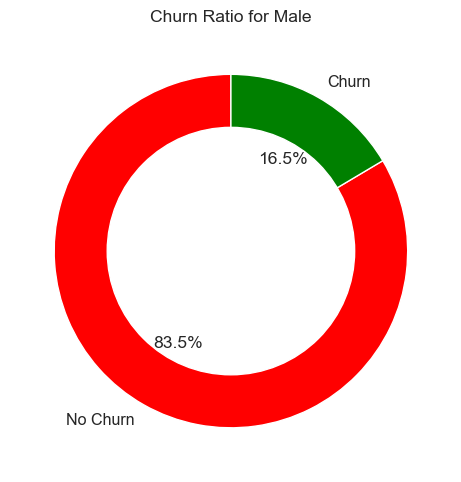

In [22]:
gender_counts=df.groupby("gender")["churn"].value_counts(normalize=True).unstack().fillna(0)
for gender in gender_counts.index:
  plt.figure(figsize=(5,5))
  plt.pie(gender_counts.loc[gender],labels=["No Churn","Churn"],autopct="%1.1f%%",startangle=90,colors=["red","green"])
  centre=plt.Circle((0,0),0.70,fc="white")
  fig=plt.gcf()
  fig.gca().add_artist(centre)
  plt.title(f"Churn Ratio for {gender}")
  plt.tight_layout()
  plt.show()

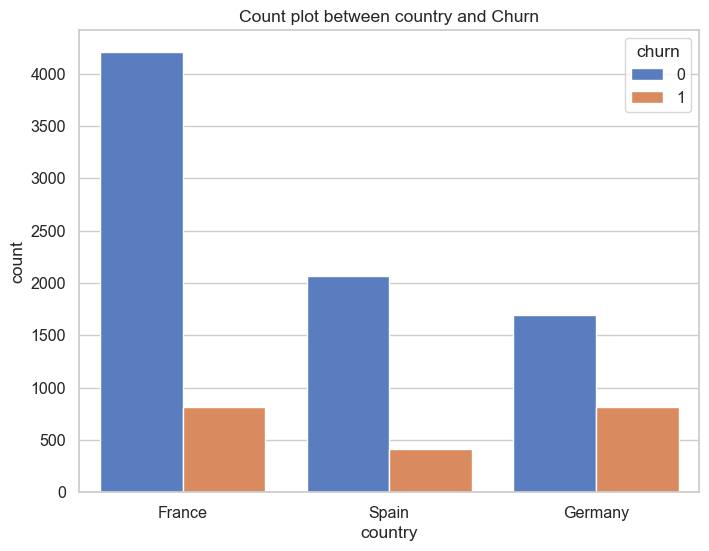

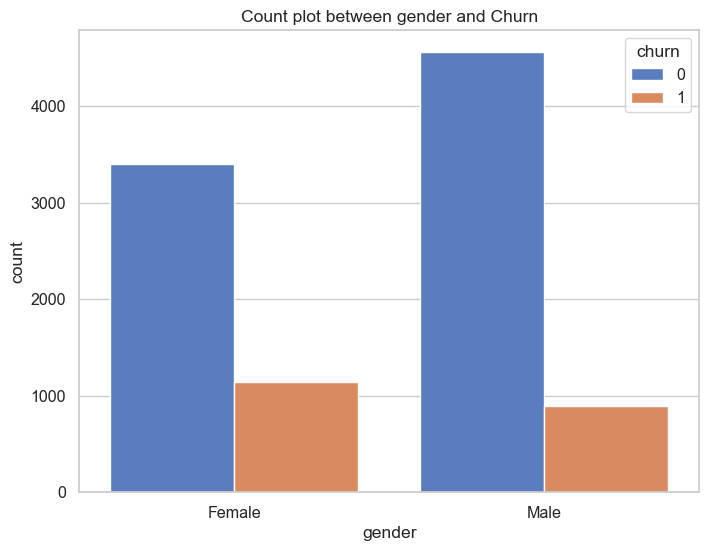

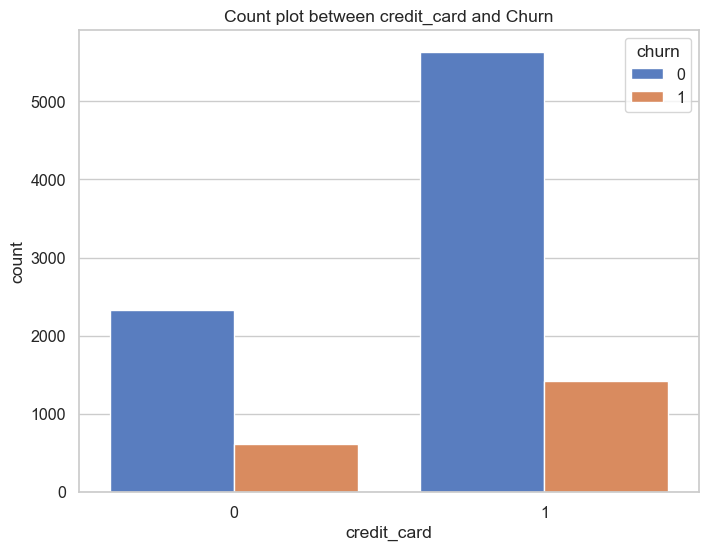

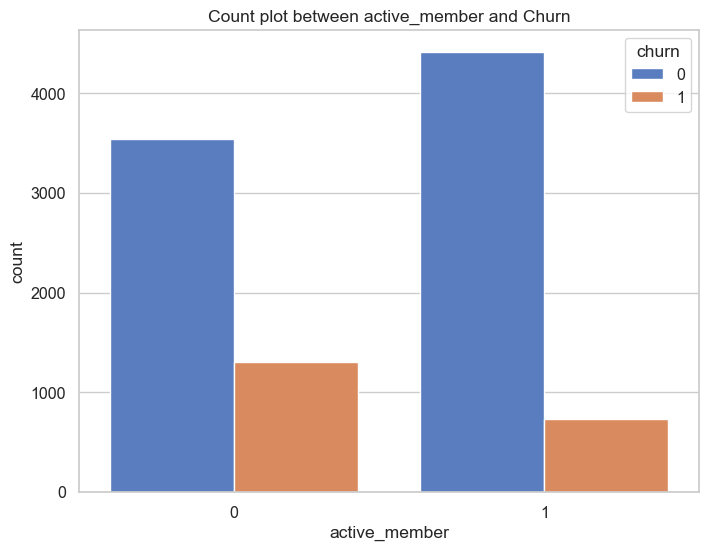

In [23]:
cat_cols=["country","gender","credit_card","active_member"]
for c in cat_cols:
  plt.figure(figsize=(8,6))
  sns.countplot(df,x=c,hue="churn")
  plt.title(f"Count plot between {c} and Churn")
  plt.show()

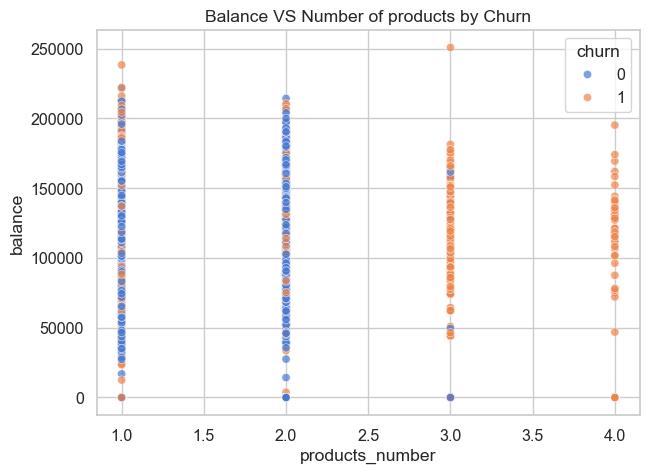

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x="products_number",y="balance",hue="churn",alpha=0.7)
plt.title("Balance VS Number of products by Churn")
plt.show()

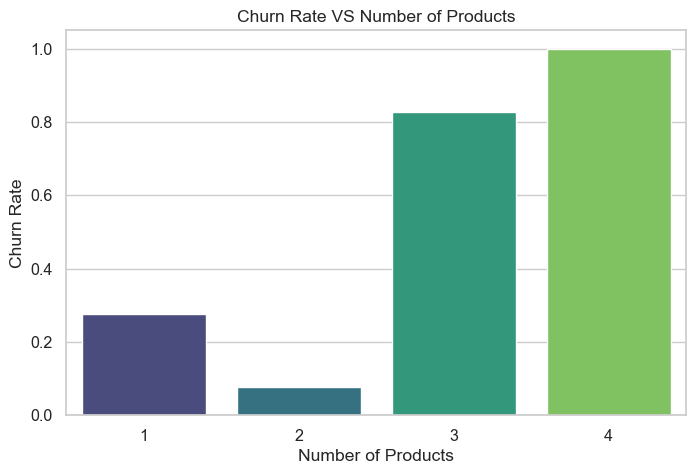

In [25]:
churn_rate=df.groupby("products_number")["churn"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate,x="products_number",y="churn",palette="viridis")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")
plt.title("Churn Rate VS Number of Products")
plt.show()

# **Feature Engineering**

In [27]:
df_fe=df.copy()

In [28]:
df_fe["balance_per_product"]=df_fe["balance"] / (df["products_number"].replace(0,np.nan))
df_fe["balance_per_product"].fillna(0,inplace=True)

df_fe["salary_balance_ratio"]=df_fe["estimated_salary"] / (df_fe["balance"].replace(0,np.nan))
df_fe["salary_balance_ratio"].replace([np.inf,-np.inf],np.nan,inplace=True)
df_fe["salary_balance_ratio"].fillna(df_fe["salary_balance_ratio"].median(),inplace=True)

bins=[0,25,35,45,55,65,100]
labels=["<25","25-34","35-44","45-54","55-64","65+"]
df_fe["age_group"]=pd.cut(df_fe["age"],bins=bins,labels=labels)

df_fe["tenure_bucket"]=pd.cut(df_fe["tenure"],bins=[-1,0,2,5,10,100],labels=["0","1-2","3-5","6-10","10+"])

df_fe["high_pressue"]=(df_fe["balance"] > df_fe["balance"].quantile(0.75)).astype(int)

In [29]:
df_fe.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,balance_per_product,salary_balance_ratio,age_group,tenure_bucket,high_pressue
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.839258,35-44,1-2,0
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,83807.860000,1.342864,35-44,1-2,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,53220.266667,0.713585,35-44,6-10,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.839258,35-44,1-2,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,125510.820000,0.630098,35-44,1-2,0


In [30]:
y=df_fe["churn"]

In [31]:
le=LabelEncoder()
df_fe["country"]=le.fit_transform(df_fe["country"])
df_fe["gender"]=le.fit_transform(df_fe["gender"])

In [32]:
x=df_fe.drop(["customer_id","balance_per_product","salary_balance_ratio","age_group","tenure_bucket","high_pressue","churn"],axis=1)

In [33]:
ss=StandardScaler()
ss_x=ss.fit_transform(x)
ss_x=pd.DataFrame(ss_x,columns=x.columns)
ss_x

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,-0.326221,-0.901886,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,1.515067,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,-0.901886,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687
3,0.501521,-0.901886,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918
4,2.063884,1.515067,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276
...,...,...,...,...,...,...,...,...,...,...
9995,1.246488,-0.901886,0.912419,0.007457,-0.004426,-1.225848,0.807737,0.646092,-1.030670,-0.066419
9996,-1.391939,-0.901886,0.912419,-0.373958,1.724464,-0.306379,-0.911583,0.646092,0.970243,0.027988
9997,0.604988,-0.901886,-1.095988,-0.278604,0.687130,-1.225848,-0.911583,-1.547768,0.970243,-1.008643
9998,1.256835,0.306591,0.912419,0.293517,-0.695982,-0.022608,0.807737,0.646092,-1.030670,-0.125231


In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [36]:
models={
    "LogisticRegression":LogisticRegression(max_iter=500),
    "RandomForest":RandomForestClassifier(n_estimators=200,random_state=42),
    "GradientBoosting":GradientBoostingClassifier(n_estimators=200,random_state=42),
    "AdaBoost":AdaBoostClassifier(n_estimators=200,random_state=42),
    "SVC":SVC(probability=True,random_state=42)
}

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results={}
for name,model in models.items():
  scores=cross_val_score(model,x_train,y_train,cv=cv,scoring="accuracy")
  results[name]=scores
  print(f"{name} Accuracy: {scores.mean()}")


LogisticRegression Accuracy: 0.8081250000000001
RandomForest Accuracy: 0.85975
GradientBoosting Accuracy: 0.860375
AdaBoost Accuracy: 0.852375
SVC Accuracy: 0.79625


In [37]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

best_name=max(results.keys(),key=lambda k:results[k].mean())
best_model=models[best_name]
bestmodel=best_model.fit(x_train,y_train)
y_test_pred_best=bestmodel.predict(x_test)
accuracy_val=accuracy_score(y_test,y_test_pred_best)
print(f"Best Model Accuracy: {accuracy_val}")
precision_val=precision_score(y_test,y_test_pred_best)
print(f"Best Model Precision: {precision_val}")
recall_val=recall_score(y_test,y_test_pred_best)
print(f"Best Model Recall: {recall_val}")
f1_val=f1_score(y_test,y_test_pred_best)
print(f"Best Model F1 Score: {f1_val}")
roc_auc_val=roc_auc_score(y_test,y_test_pred_best)
print(f"Best Model ROC AUC Score: {roc_auc_val}")

Best Model Accuracy: 0.87
Best Model Precision: 0.7905138339920948
Best Model Recall: 0.4914004914004914
Best Model F1 Score: 0.6060606060606061
Best Model ROC AUC Score: 0.729064966353102


In [40]:
import joblib

In [42]:
joblib.dump(bestmodel,"model.pkl")


['model.pkl']

In [44]:
joblib.dump(ss,"scaler.pkl")

['scaler.pkl']